# **Khoroshilova Elizaveta**


In [ ]:
import os
import random
from pathlib import Path
import json
import shutil
import zipfile
from urllib.error import URLError
from urllib.request import urlretrieve
import cv2
import matplotlib_inline
import matplotlib.pyplot as plt
import numpy as np
import numpy.testing as npt
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from PIL import Image, ImageDraw
from skimage import measure
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import vgg13, VGG13_Weights
from tqdm import tqdm

%matplotlib inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf', 'svg')


__init__ initializing dataset objects, saves paths to images and masks
__len__  PyTorch needs to know how many total items are in your dataset so it knows when an epoch is finished

__getitem__ can search for specific image, read it, use colour palette, read masks, apply transformations

In [ ]:
class PhotosDataset(Dataset):
    """Dataset for loading images and masks with synchronized transformations."""

    def __init__(self, images_dir, target_dir=None, transforms=None):
        """Initializes the dataset.

        Args:
            images_dir (str): Path to the folder with source images.
            target_dir (str, optional): Path to the folder with masks.
            transforms (callable, optional): Augmentations to apply to (image, mask).
        """
        self.images_dir = images_dir
        self.target_dir = target_dir
        self.transforms = transforms
        self.image_filenames = sorted(os.listdir(images_dir))

    def __len__(self):
        """Returns the total number of images."""
        return len(self.image_filenames)

    def __getitem__(self, idx):
        """Fetches the image and its corresponding mask at the given index.

        Args:
            idx (int): Index of the sample.

        Returns:
            tuple: (image, mask) processed and ready for the model.
        """
        img_name = self.image_filenames[idx]
        img_path = os.path.join(self.images_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = None
        if self.target_dir is not None:
            mask_name = img_name.split('.')[0] + '.png'
            mask_path = os.path.join(self.target_dir, mask_name)
            mask = cv2.imread(mask_path, 0)

        image = Image.fromarray(image)
        if mask is not None:
            mask = Image.fromarray(mask)

        if self.transforms is not None:
            if mask is not None:
                image, mask = self.transforms(image, mask)
            else:
                image, _ = self.transforms(image, None)

        return image, mask

The constructor of the standard `ImageFolder' takes the `transform` parameter (and sometimes `target_transform`).

They are used to convert uploaded images (usually `PIL.Image`) or targets into tensors of the desired type.
Torchvision includes the transformations module for standard examples of such transformations. Transformations can contain random transformations, which is the easiest way to implement data augmentation.
When defining a custom transformer, in addition to the constructor, you only need to implement the `__call__` method.:

```python
class HorizontalFlip(object):
    def __init__(self, mode=0):
        self.method = mode

    def __call__(self, img):
        """
        Args:
            img (PIL.Image): Image to be flipped.

        Returns:
            PIL.Image: Randomly flipped image.
        """
        if self.method:
            return img.transpose(Image.FLIP_LEFT_RIGHT)
        return img

```


In [ ]:
class ComposePair:
    """Chains multiple transformations together.

    Applies a list of paired transformations sequentially to both the image
    and its corresponding mask to ensure they remain perfectly synchronized.

    Attributes:
        transforms_list (list): A list of transformation objects to apply.
    """
    def __init__(self, transforms_list):
        self.transforms_list = transforms_list

    def __call__(self, image, mask):
        for t in self.transforms_list:
            image, mask = t(image, mask)
        return image, mask

class RandomFlipPair:
    """Randomly flips the image and mask horizontally.

    This provides spatial invariance, helping the model generalize to
    different orientations of the human subject.

    Attributes:
        p (float): Probability of applying the transformation.
    """
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, image, mask):
        if random.random() < self.p:
            image = TF.hflip(image)
            mask = TF.hflip(mask)
        return image, mask

class RandomCutoutPair:
    """Randomly adds a black square to both the image and the mask.

    This technique simulates occlusions (e.g., objects blocking the person),
    forcing the network to recognize the human silhouette from partial features.

    Attributes:
        p (float): Probability of applying the transformation.
        size (int): The width and height of the black square in pixels.
    """
    def __init__(self, p=0.5, size=50):
        self.p = p
        self.size = size

    def __call__(self, image, mask):
        if random.random() < self.p:
            w, h = image.size
            x0 = random.randint(0, w - self.size)
            y0 = random.randint(0, h - self.size)
            x1 = x0 + self.size
            y1 = y0 + self.size
            ImageDraw.Draw(image).rectangle([x0, y0, x1, y1], fill=(0, 0, 0))
            ImageDraw.Draw(mask).rectangle([x0, y0, x1, y1], fill=0)
        return image, mask

class RandomBrightnessPair:
    """Randomly adjusts the brightness of the image.

    This increases model resilience to various lighting and exposure conditions.
    The mask remains unchanged since lighting does not affect the true shape.

    Attributes:
        p (float): Probability of applying the transformation.
        limit (float): Maximum factor by which to increase/decrease brightness.
    """
    def __init__(self, p=0.5, limit=0.2):
        self.p = p
        self.limit = limit

    def __call__(self, image, mask):
        if random.random() < self.p:
            factor = 1.0 + random.uniform(-self.limit, self.limit)
            image = TF.adjust_brightness(image, factor)
        return image, mask

class RandomBackgroundPair:
    """Randomly replaces the background of the image.

    Uses the binary mask to composite the human subject onto a completely
    new, random background. This prevents the model from overfitting to
    specific environmental contexts (like room colors or landscapes).

    Attributes:
        p (float): Probability of applying the transformation.
        bg_paths (list): List of file paths to the available background images.
    """
    def __init__(self, p=0.5, bg_dir=None):
        self.p = p
        self.bg_paths = []
        if bg_dir and os.path.exists(bg_dir):
            self.bg_paths = [os.path.join(bg_dir, f) for f in os.listdir(bg_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

    def __call__(self, image, mask):
        if random.random() < self.p and len(self.bg_paths) > 0:
            bg_path = random.choice(self.bg_paths)
            bg = Image.open(bg_path).convert("RGB")
            bg = bg.resize(image.size)
            # Create a binary mask for the composite function
            binary_mask = mask.point(lambda p: 255 if p > 0 else 0, mode="1")
            image = Image.composite(image, bg, binary_mask)
        return image, mask

class ToTensorAndNormalizePair:
    """Converts PIL Images to PyTorch Tensors and normalizes them.

    Applies ImageNet standard normalization (Mean/Std) to the image for
    compatibility with the pre-trained VGG13 encoder. Converts the mask
    into a binary float tensor (0.0 to 1.0) with an added channel dimension.
    """
    def __init__(self):
        self.to_tensor = transforms.ToTensor()
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __call__(self, image, mask):
        # Image transformation
        image = self.to_tensor(image)
        image = self.normalize(image)

        # Mask transformation
        mask_tensor = torch.as_tensor(np.array(mask), dtype=torch.float32)
        if len(mask_tensor.shape) == 2:
            mask_tensor = mask_tensor.unsqueeze(0)  # Add channel dimension

        # Ensure mask is in [0, 1] range
        if mask_tensor.max() > 1:
            mask_tensor = mask_tensor / 255.0

        return image, mask_tensor

In [ ]:
def show_idx_image(dataset, idx):
    """Visualizes an image and its corresponding mask from the dataset.

    This function fetches a tensor image and mask by index, reverses the
    ImageNet normalization applied during preprocessing, converts the tensors
    back to numpy arrays, and plots them side-by-side.

    Args:
        dataset (torch.utils.data.Dataset): The dataset containing image-mask pairs.
        idx (int): The index of the sample to visualize.

    Returns:
        None. Displays a matplotlib plot.
    """
    image, mask = dataset[idx]

    # Convert from PyTorch format [C, H, W] to matplotlib format [H, W, C]
    image = image.permute(1, 2, 0).numpy()

    # Denormalize: reverse the ImageNet normalization (multiply by std, add mean)
    image = (image * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])

    # Clip values to [0, 1] to prevent matplotlib from throwing warnings
    image = np.clip(image, 0, 1)

    # Remove the channel dimension from the mask [1, H, W] -> [H, W]
    mask = mask.squeeze(0).numpy()

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(6, 4))

    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].set_axis_off()

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title("Binary Mask")
    axes[1].set_axis_off()

    fig.tight_layout()
    plt.show()

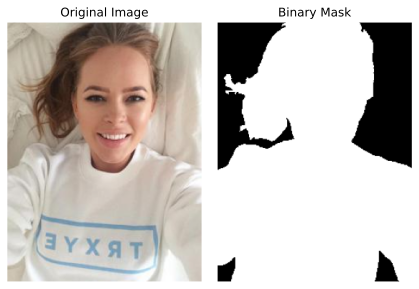

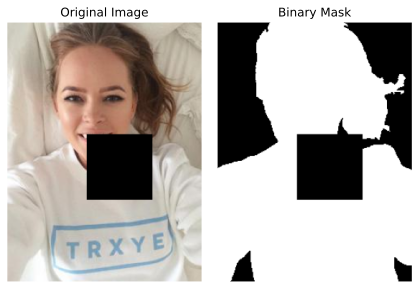

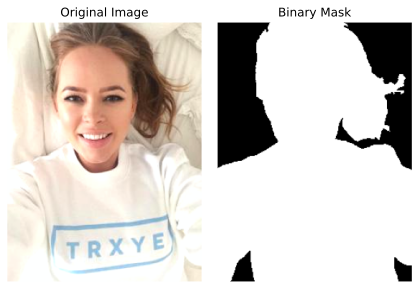

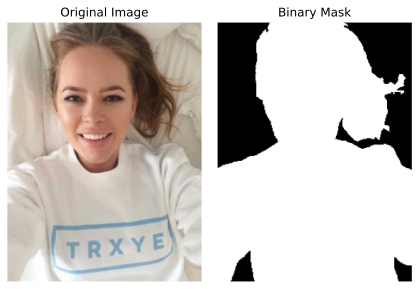

In [ ]:
def run_augmentation_smoke_tests(data_path: str, idx_to_show: int = 0):
    """Visualize each augmentation pipeline on one training sample.

    Args:
        data_path (str): Root ``people_data`` directory.
        idx_to_show (int): Dataset index to render.

    Returns:
        None
    """
    test_modules = {
        "1. Flip": ComposePair([RandomFlipPair(p=1.0), ToTensorAndNormalizePair()]),
        "2. Cutout": ComposePair([RandomCutoutPair(p=1.0, size=80), ToTensorAndNormalizePair()]),
        "3. Brightness": ComposePair([RandomBrightnessPair(p=1.0, limit=0.4), ToTensorAndNormalizePair()]),
        "4. Background": ComposePair(
            [RandomBackgroundPair(p=1.0, bg_dir="path/to/backgrounds"), ToTensorAndNormalizePair()]
        ),
    }
    for _name, transform in test_modules.items():
        temp_dataset = PhotosDataset(
            images_dir=os.path.join(data_path, "train"),
            target_dir=os.path.join(data_path, "train_mask"),
            transforms=transform,
        )
        show_idx_image(temp_dataset, idx_to_show)


run_augmentation_smoke_tests(DATA_PATH, idx_to_show=0)
